In [1]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

In [2]:
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import jax
import jax.numpy as jnp

# Configure JAX to use only the CPU
# jax.config.update('jax_platform_name', 'cpu') 

print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange


# Utility function to convert GPU/JAX arrays to CPU/NumPy arrays

def to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(jax.device_get(x)) if isinstance(x, (jnp.ndarray, np.ndarray)) else x,
        tree,
    )

def as_f32_scalar(x):
    # Make sure to extract as a scalar (float32) even if it's an array/DeviceArray
    return np.asarray(x, dtype=np.float32).reshape(()).item()

jax: 0.7.2
devices: [CudaDevice(id=0)]
Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


In [15]:
GRID_SIZE = 64                  # cryo-ET data will be resampled to GRID_SIZE^3 (64 * 64 * 64)
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Parameters
lambda_1 = 1000000      # Weight for boundary loss (data loss)
lambda_2 = 100          # Weight for physics loss
shape = "090_TS49_S3_denoised_normalized"
sdf_pretrain="sphere"   # sphere or plane
num_collocation = 10000
num_steps = 10000
save_interval = 100
threshold = 0.8

# Initialize JAX random key
key = jax.random.PRNGKey(0)

# Create train state
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, threshold = threshold, sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}, threshold: {state.threshold}")

### LOAD MRC DATA #####
mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))


x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/{shape}/lambda_{lambda_1}_{lambda_2}")

# --- keep the same schema for step 0 ---
init_d = initial_loss(state, x_train, cryoET_data)     # Get the dictionary of initial losses
init_total = init_d.get("total_loss", init_d.get("total", init_d.get("loss", 0.0)))
init_data  = init_d.get("data_loss",  init_d.get("data",  0.0))
init_phys  = init_d.get("physics_loss", init_d.get("phys", init_d.get("physics", 0.0)))

payload0 = {
    "state": to_numpy(state),
    "loss": {
        "step":         np.asarray([0], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(init_total)], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(init_data)],  dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(init_phys)],  dtype=np.float32),
    }
}

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    target=payload0,
    step=0,
    overwrite=False,
    keep=NUM_CHECKPOINTS_TO_KEEP,
)

loss_history = []

for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)

    loss_history.append({
    "step":  step + 1,
    "total_loss":   loss_val,
    "data_loss":    loss_data_val,
    "physics_loss": loss_physics_val
    })

    if (step + 1) % save_interval == 0:
        batched_loss = {
          "step":         np.asarray([e["step"] for e in loss_history], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(e["total_loss"])   for e in loss_history], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(e["data_loss"])    for e in loss_history], dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(e["physics_loss"]) for e in loss_history], dtype=np.float32),
        }

        payload = {
            "state": to_numpy(state),  # 항상 CPU NumPy로
            "loss":  batched_loss
        }

        checkpoints.save_checkpoint(
            ckpt_dir=checkpoint_dir,
            target=payload,
            step=step + 1,
            overwrite=False,
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        # print(f"Checkpoint saved at step {step+1}")
        loss_history = []


Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 100, threshold: 0.8
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.0
Cryo-ET Data Max: 1.0
Cryo-ET Unique Values: [0.00000000e+00 1.04984458e-04 1.12257934e-04 ... 9.99991834e-01
 9.99996006e-01 1.00000000e+00]


  0%|          | 0/10000 [00:00<?, ?it/s]

## Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/experimental/090_TS49_S3_denoised_normalized/lambda_1000000_200


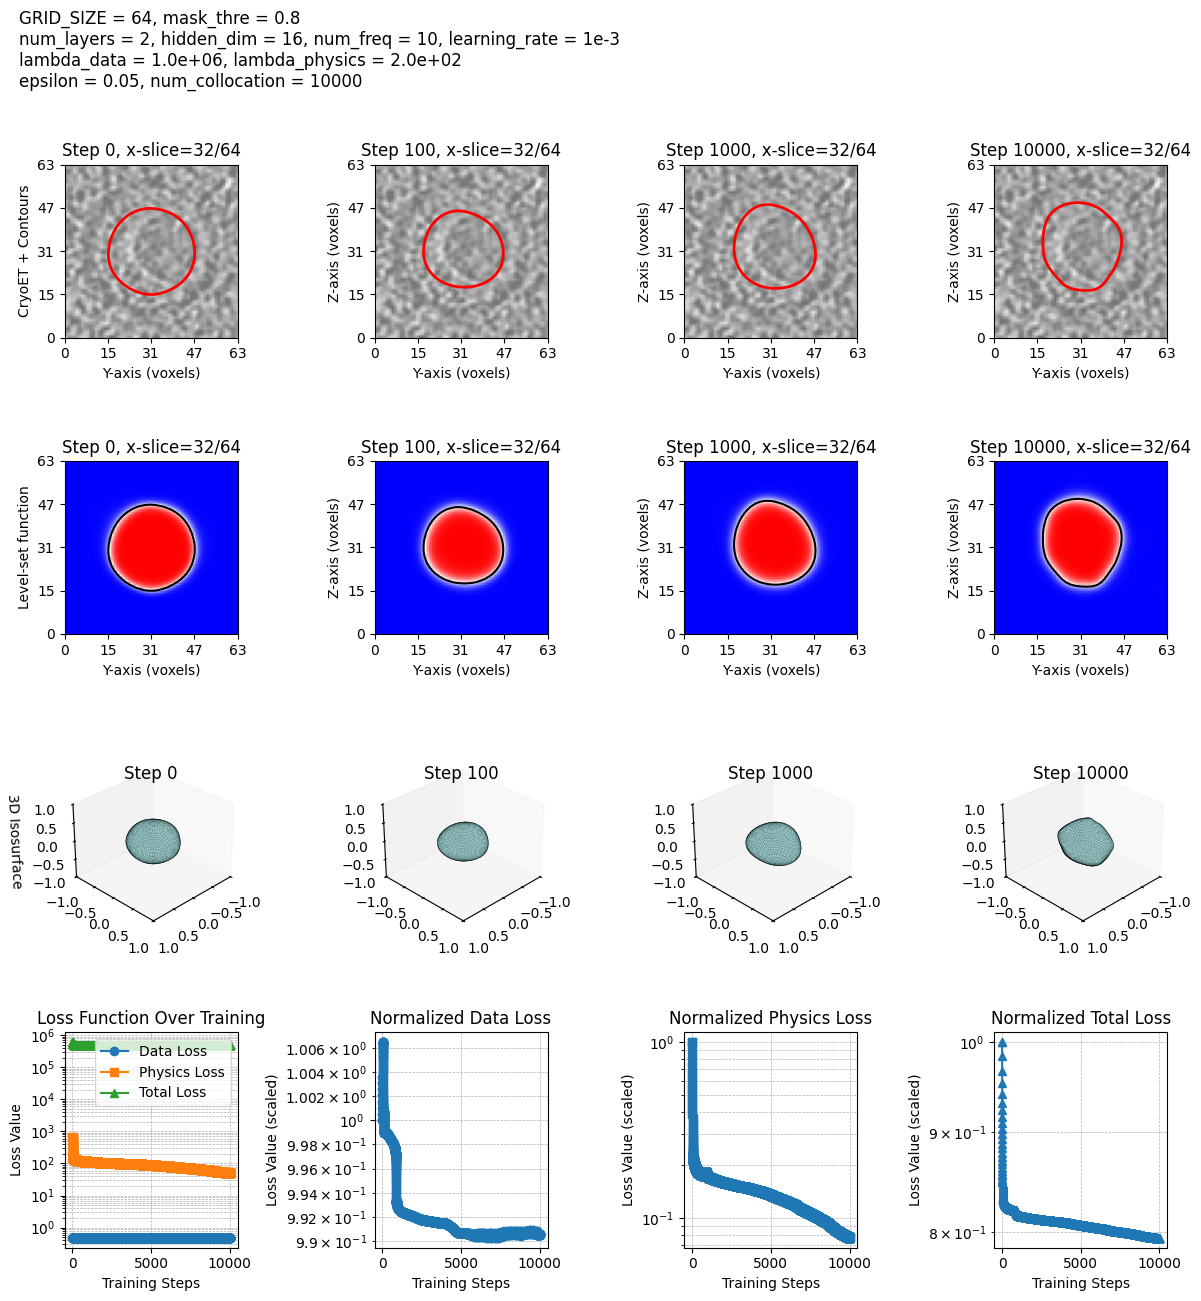

In [16]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 200
num_collocation = 10000
num_layers = 2

steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/{shape}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/experimental/downsampled/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="x", thresholding=False)
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="x")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


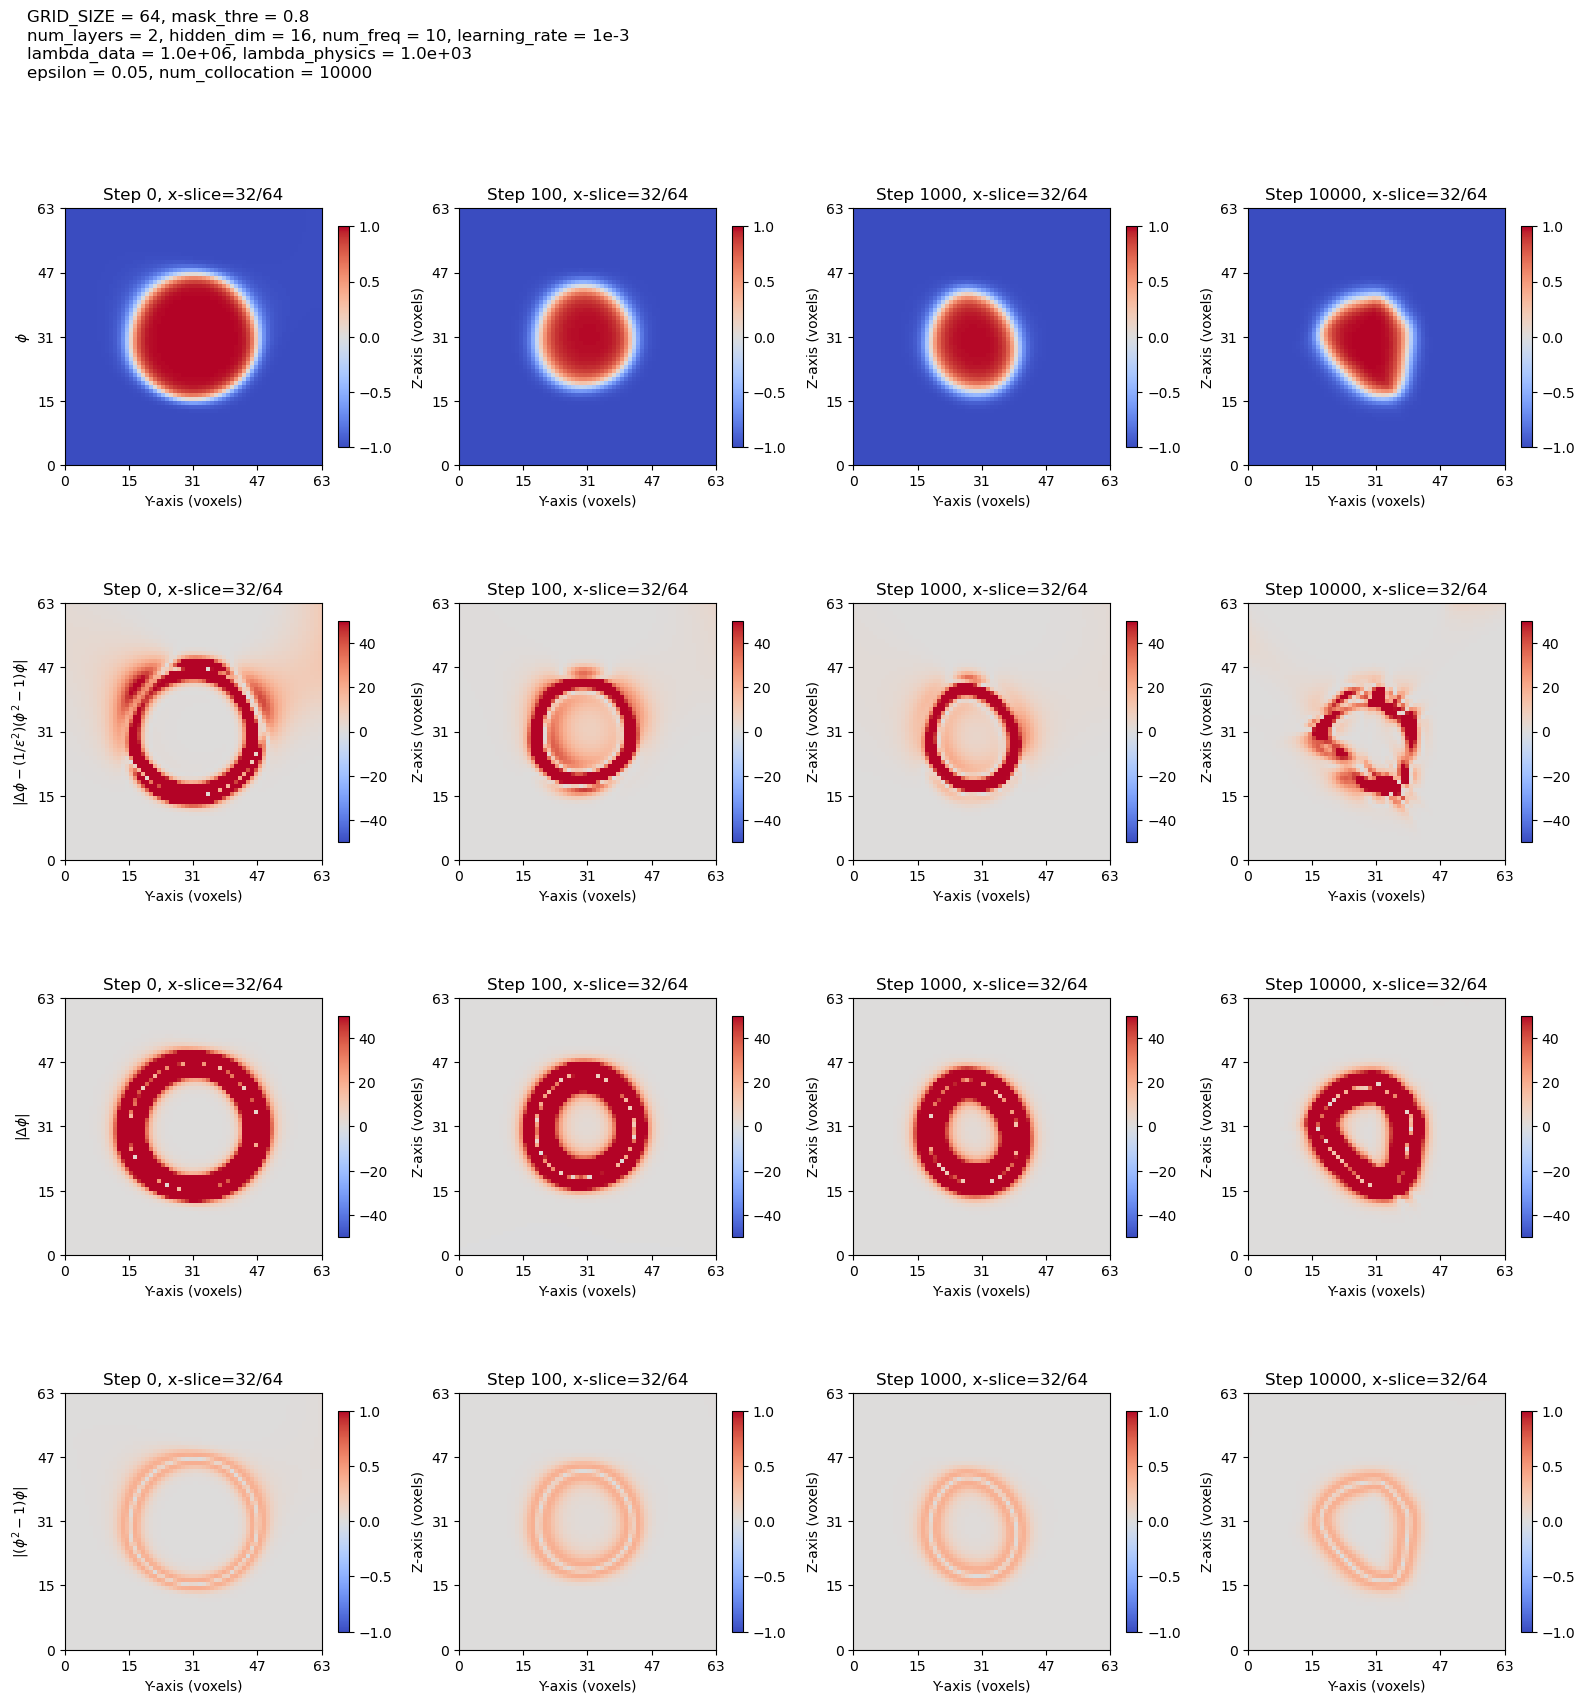

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05

# steps_to_visualize = [0, 200, 600, 1000]
steps_to_visualize = [0, 100, 1000, 10000]


# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/experimental/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: residual
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-50, vmax=50)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "residual", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 3: laplacian
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="laplacian",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-50, vmax=50)
    # visualize_physics_loss(ax, step, checkpoint_data[step], epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=1e5)
    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi|$")

# Row 4: gradient
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           # checkpoint=checkpoint_data[step], component="grad_norm2",
                           checkpoint=checkpoint_data[step], component="nonlinear",
                           grid_size=GRID_SIZE, slice_index=32, axis="x", vmin=-1, vmax=1)
    if i == 0:
        ax.set_ylabel(r"$|(\phi^2 - 1)\phi|$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()